# Qwen 指令微调项目

这个 notebook 是第一个实战项目的完整执行版本。目标很明确：

1. 使用 `Qwen/Qwen3.5-4B` 作为原始基座
2. 使用 `PEFT + LoRA` 完成 5 组微调实验
3. 把原始基座和 5 组微调结果放在一起比较
4. 自动产出训练曲线、验证曲线、样本对比表、实验汇总表

## 当前实验矩阵

- 原始基座：`baseline_raw_qwen3.5_4b`
- `exp-001-baseline-lora`
- `exp-002-higher-rank`
- `exp-003-lower-lr`
- `exp-004-higher-dropout`
- `exp-005-longer-train`

## 当前评测方式

1. train loss
2. eval loss
3. JSON / 三点列表 / 单句解释等规则评测
4. 固定样本的定性输出对比

这份 notebook 不再只是结构骨架，而是完整实验工作台。


## 1. 导入依赖

当前训练栈：

- `transformers`
- `datasets`
- `peft`
- `accelerate`
- `trl`
- `matplotlib`
- `seaborn`
- `pandas`

当前微调方式：`PEFT + LoRA`。


In [1]:
from pathlib import Path
import json
from dataclasses import dataclass, asdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, PeftModel

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 160)


## 2. 项目路径和基础配置

这里统一定义项目路径、数据路径、运行目录和基础模型。


In [2]:
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_DIR = NOTEBOOK_DIR.parent
else:
    PROJECT_DIR = Path('/Users/yezibin/Project/learn-ft-and-rl/project/qwen-instruction-sft')

DATA_DIR = PROJECT_DIR / 'data'
RUNS_DIR = PROJECT_DIR / 'runs'
TRAIN_PATH = DATA_DIR / 'train' / 'train_v0.1.jsonl'
EVAL_PATH = DATA_DIR / 'eval' / 'eval_v0.1.jsonl'

BASE_MODEL = 'Qwen/Qwen3.5-2B'
FALLBACK_MODEL = 'Qwen/Qwen3.5-0.8B'
MAX_LENGTH = 1024
MAX_NEW_TOKENS = 128
SEED = 42

PROJECT_DIR, TRAIN_PATH.exists(), EVAL_PATH.exists()


(PosixPath('/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft'),
 True,
 True)

## 3. 读取数据

我们使用 `jsonl` 数据，每一行是一条 `messages + metadata` 样本。


In [3]:
def load_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

train_rows = load_jsonl(TRAIN_PATH)
eval_rows = load_jsonl(EVAL_PATH)
len(train_rows), len(eval_rows)


(40, 10)

In [4]:
pd.DataFrame([r['metadata'] for r in train_rows]).value_counts('task_type').sort_index()


task_type
definition    12
formatting     6
multi_turn     6
qa             8
rewrite        8
Name: count, dtype: int64

In [5]:
train_rows[0]


{'id': 'train-0001',
 'messages': [{'role': 'system', 'content': '你是一个有帮助的助手。'},
  {'role': 'user', 'content': '请用一句话解释什么是机器学习。'},
  {'role': 'assistant', 'content': '机器学习是让计算机从数据中学习规律并完成任务的方法。'}],
 'metadata': {'source': 'manual',
  'task_type': 'definition',
  'language': 'zh',
  'difficulty': 'easy',
  'version': 'v0.1'}}

## 4. 加载 tokenizer 并预览 chat template

Qwen 的训练和推理必须使用一致的 chat template。


In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

preview_text = tokenizer.apply_chat_template(
    train_rows[0]['messages'],
    tokenize=False,
    add_generation_prompt=False,
)
print(preview_text)

<|im_start|>system
你是一个有帮助的助手。<|im_end|>
<|im_start|>user
请用一句话解释什么是机器学习。<|im_end|>
<|im_start|>assistant
<think>

</think>

机器学习是让计算机从数据中学习规律并完成任务的方法。<|im_end|>



## 5. 转成训练文本

这里把 messages 统一转换成模型输入文本，方便后续 tokenization。


In [7]:
def to_chat_text(row):
    return {
        'id': row['id'],
        'text': tokenizer.apply_chat_template(
            row['messages'],
            tokenize=False,
            add_generation_prompt=False,
        ),
        'task_type': row['metadata']['task_type'],
    }

train_text_rows = [to_chat_text(r) for r in train_rows]
eval_text_rows = [to_chat_text(r) for r in eval_rows]
train_text_rows[0]['text'][:400]


'<|im_start|>system\n你是一个有帮助的助手。<|im_end|>\n<|im_start|>user\n请用一句话解释什么是机器学习。<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n机器学习是让计算机从数据中学习规律并完成任务的方法。<|im_end|>\n'

## 6. 构建 Dataset 并 tokenize

第一版先用标准 causal language modeling 方式构建训练样本。


In [8]:
train_ds = Dataset.from_list(train_text_rows)
eval_ds = Dataset.from_list(eval_text_rows)
train_ds, eval_ds


(Dataset({
     features: ['id', 'text', 'task_type'],
     num_rows: 40
 }),
 Dataset({
     features: ['id', 'text', 'task_type'],
     num_rows: 10
 }))

In [9]:
def tokenize_batch(batch):
    out = tokenizer(
        batch['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )
    out['labels'] = out['input_ids'].copy()
    return out

tokenized_train = train_ds.map(tokenize_batch, batched=True)
tokenized_eval = eval_ds.map(tokenize_batch, batched=True)
tokenized_train[0].keys()


Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

dict_keys(['id', 'text', 'task_type', 'input_ids', 'attention_mask', 'labels'])

## 7. 实验配置

这里一次性定义 5 组 LoRA 实验，并保留原始基座作为对照组。


In [10]:
@dataclass
class ExperimentConfig:
    name: str
    output_dir: str
    lora_r: int
    lora_alpha: int
    lora_dropout: float
    learning_rate: float
    num_train_epochs: int
    per_device_train_batch_size: int
    gradient_accumulation_steps: int

baseline_name = 'baseline_raw_qwen3.5_2b'

experiments = [
    ExperimentConfig(
        name='exp-001-baseline-lora',
        output_dir=str(RUNS_DIR / 'exp-001'),
        lora_r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        learning_rate=2e-4,
        num_train_epochs=3,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
    ),
    ExperimentConfig(
        name='exp-002-higher-rank',
        output_dir=str(RUNS_DIR / 'exp-002'),
        lora_r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        learning_rate=2e-4,
        num_train_epochs=3,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
    ),
    ExperimentConfig(
        name='exp-003-lower-lr',
        output_dir=str(RUNS_DIR / 'exp-003'),
        lora_r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        learning_rate=1e-4,
        num_train_epochs=3,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
    ),
    ExperimentConfig(
        name='exp-004-higher-dropout',
        output_dir=str(RUNS_DIR / 'exp-004'),
        lora_r=16,
        lora_alpha=32,
        lora_dropout=0.10,
        learning_rate=2e-4,
        num_train_epochs=3,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
    ),
    ExperimentConfig(
        name='exp-005-longer-train',
        output_dir=str(RUNS_DIR / 'exp-005'),
        lora_r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        learning_rate=2e-4,
        num_train_epochs=5,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,
    ),
]

pd.DataFrame([asdict(exp) for exp in experiments])


,name,output_dir,lora_r,lora_alpha,lora_dropout,learning_rate,num_train_epochs,per_device_train_batch_size,gradient_accumulation_steps
0,exp-001-baseline-lora,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-001,8,16,0.05,0.0002,3,1,8
1,exp-002-higher-rank,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-002,16,32,0.05,0.0002,3,1,8
2,exp-003-lower-lr,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-003,16,32,0.05,0.0001,3,1,8
3,exp-004-higher-dropout,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-004,16,32,0.10,0.0002,3,1,8
4,exp-005-longer-train,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-005,16,32,0.05,0.0002,5,1,8


## 8. 构建训练器

这里是 PEFT + LoRA 的核心部分。当前不是 full fine-tuning，而是只训练 adapter。


In [11]:
def build_model_and_targets(model_name=BASE_MODEL):
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        trust_remote_code=True,
        device_map='auto',
        torch_dtype='auto',
    )
    lora_targets = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'up_proj', 'down_proj', 'gate_proj']
    return model, lora_targets


def build_trainer(exp_cfg: ExperimentConfig):
    model, lora_targets = build_model_and_targets()
    peft_cfg = LoraConfig(
        r=exp_cfg.lora_r,
        lora_alpha=exp_cfg.lora_alpha,
        lora_dropout=exp_cfg.lora_dropout,
        target_modules=lora_targets,
        bias='none',
        task_type='CAUSAL_LM',
    )
    model = get_peft_model(model, peft_cfg)
    args = TrainingArguments(
        output_dir=exp_cfg.output_dir,
        learning_rate=exp_cfg.learning_rate,
        num_train_epochs=exp_cfg.num_train_epochs,
        per_device_train_batch_size=exp_cfg.per_device_train_batch_size,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=exp_cfg.gradient_accumulation_steps,
        eval_strategy='epoch',
        save_strategy='epoch',
        logging_steps=5,
        report_to='none',
        bf16=True,
        seed=SEED,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_eval,
        data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
    )
    return trainer


## 9. 执行全部五组实验

这一格会顺序跑完五个实验，并把日志和验证指标写入各自的 `runs/exp-xxx/` 目录。


In [12]:
def run_all_experiments(experiments):
    histories = []
    for exp in experiments:
        run_dir = Path(exp.output_dir)
        run_dir.mkdir(parents=True, exist_ok=True)
        print(f'===== Running {exp.name} =====')
        trainer = build_trainer(exp)
        trainer.train()
        eval_result = trainer.evaluate()

        history = pd.DataFrame(trainer.state.log_history)
        history['experiment'] = exp.name
        history.to_csv(run_dir / 'log_history.csv', index=False)

        with open(run_dir / 'eval_metrics.json', 'w', encoding='utf-8') as f:
            json.dump(eval_result, f, ensure_ascii=False, indent=2)

        trainer.save_model(run_dir)
        histories.append(history)
    if histories:
        return pd.concat(histories, ignore_index=True)
    return pd.DataFrame()

# 运行全部实验
history_df = run_all_experiments(experiments)
history_df.head()


===== Running exp-001-baseline-lora =====


(…)l.safetensors-00001-of-00001.safetensors:   0%|          | 0.00/4.55G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,1.839821,1.293833
2,1.076625,1.060252
3,0.880115,0.984067


...

===== Running exp-005-longer-train =====


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,1.664605,1.116615
2,0.841558,0.878609
3,0.558938,0.820782
4,0.370152,0.831300
5,0.273408,0.848275


Training Loss,Validation Loss,Epoch
0.273408,0.848275,5


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,experiment
0,1.839821,2.090538,0.000147,1.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
1,NaN,NaN,NaN,1.0,5,1.293833,2.2987,4.350,4.350,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
2,1.076625,3.459408,0.000080,2.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
3,NaN,NaN,NaN,2.0,10,1.060252,2.0392,4.904,4.904,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
4,0.880115,1.864840,0.000013,3.0,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora


## 10. 读取训练日志

如果你已经跑完实验，可以用这部分直接读回结果，不必重复训练。


In [13]:
def load_histories(run_dirs):
    frames = []
    for run_dir in run_dirs:
        csv_path = Path(run_dir) / 'log_history.csv'
        if csv_path.exists():
            frames.append(pd.read_csv(csv_path))
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

history_df = load_histories([exp.output_dir for exp in experiments])
history_df.head() if not history_df.empty else history_df


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss,experiment
0,1.839821,2.090538,0.000147,1.0,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
1,NaN,NaN,NaN,1.0,5,1.293833,2.2987,4.350,4.350,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
2,1.076625,3.459408,0.000080,2.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
3,NaN,NaN,NaN,2.0,10,1.060252,2.0392,4.904,4.904,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora
4,0.880115,1.864840,0.000013,3.0,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,exp-001-baseline-lora


## 11. 绘制训练曲线和验证曲线

这里输出两张核心图：

1. training loss comparison
2. eval loss comparison


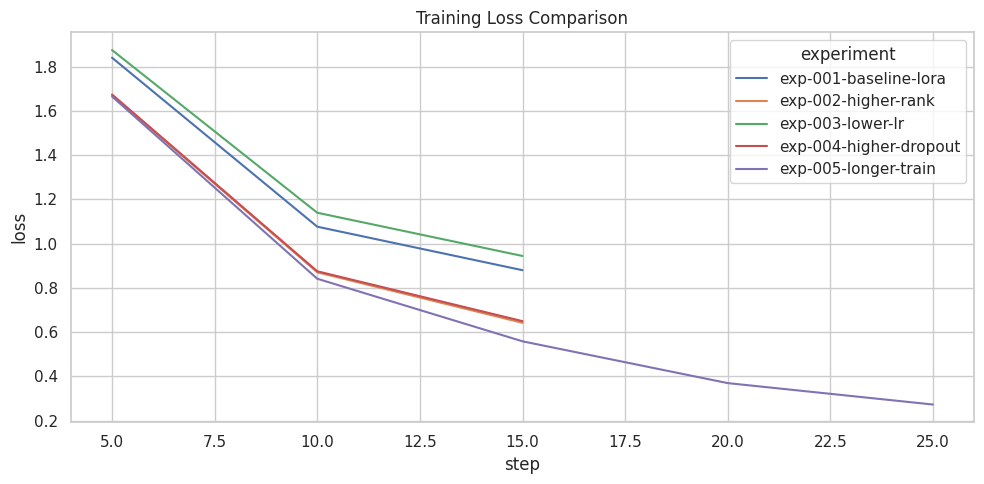

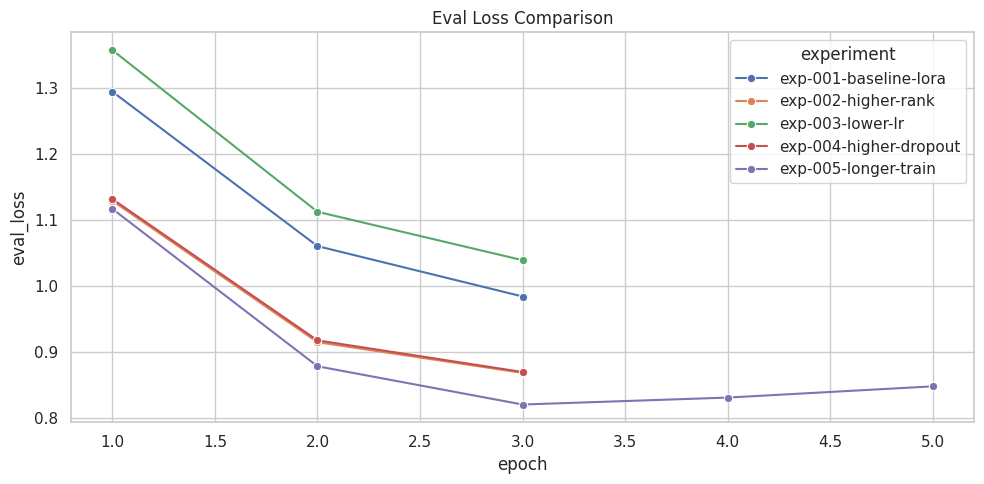

In [14]:
if not history_df.empty:
    if 'loss' in history_df.columns:
        train_loss_df = history_df.dropna(subset=['loss'])
        if not train_loss_df.empty:
            plt.figure(figsize=(10, 5))
            sns.lineplot(data=train_loss_df, x='step', y='loss', hue='experiment')
            plt.title('Training Loss Comparison')
            plt.tight_layout()
            plt.savefig(RUNS_DIR / 'training_loss_comparison.png', dpi=150)
            plt.show()

    if 'eval_loss' in history_df.columns:
        eval_loss_df = history_df.dropna(subset=['eval_loss'])
        if not eval_loss_df.empty:
            plt.figure(figsize=(10, 5))
            sns.lineplot(data=eval_loss_df, x='epoch', y='eval_loss', hue='experiment', marker='o')
            plt.title('Eval Loss Comparison')
            plt.tight_layout()
            plt.savefig(RUNS_DIR / 'eval_loss_comparison.png', dpi=150)
            plt.show()


## 12. 固定评测样本

这些样本用于和原始基座做统一对比。


In [15]:
sample_eval_cases = [
    {
        'task_type': 'definition',
        'prompt': '请用一句话解释什么是监督微调。',
        'expected_check': 'single_sentence',
    },
    {
        'task_type': 'rewrite',
        'prompt': '把下面这句话改写得更正式：这个结果还不错。',
        'expected_check': 'style_formal',
    },
    {
        'task_type': 'formatting',
        'prompt': '请把以下内容整理成三点：先准备数据，再选择模型，最后开始训练。',
        'expected_check': 'three_bullets',
    },
    {
        'task_type': 'formatting',
        'prompt': '请将下面内容输出为 JSON：任务训练，状态进行中。',
        'expected_check': 'valid_json',
    },
    {
        'task_type': 'multi_turn',
        'prompt': '我想学会总结文章，先从哪一步开始？',
        'expected_check': 'direct_helpful_answer',
    },
]

pd.DataFrame(sample_eval_cases)


,task_type,prompt,expected_check
0,definition,请用一句话解释什么是监督微调。,single_sentence
1,rewrite,把下面这句话改写得更正式：这个结果还不错。,style_formal
2,formatting,请把以下内容整理成三点：先准备数据，再选择模型，最后开始训练。,three_bullets
3,formatting,请将下面内容输出为 JSON：任务训练，状态进行中。,valid_json
4,multi_turn,我想学会总结文章，先从哪一步开始？,direct_helpful_answer


## 13. 规则评测函数

当前先做三类规则评测：

1. JSON 可解析
2. 三点列表完整
3. 单句解释约束

其他类型先保留人工判断。


In [16]:
def is_valid_json(text):
    try:
        json.loads(text)
        return True
    except Exception:
        return False


def check_three_bullets(text):
    markers = ['1.', '2.', '3.']
    return all(m in text for m in markers)


def check_single_sentence(text):
    sentence_endings = text.count('。') + text.count('!') + text.count('！') + text.count('?') + text.count('？')
    return sentence_endings <= 1


def simple_format_check(expected_check, text):
    if expected_check == 'valid_json':
        return is_valid_json(text)
    if expected_check == 'three_bullets':
        return check_three_bullets(text)
    if expected_check == 'single_sentence':
        return check_single_sentence(text)
    return None


## 14. 评测方式说明

当前评测分四层：

1. 原始基座对比
2. train / eval loss
3. 规则格式评测
4. 固定样本定性对比

结论不能只看 loss。你必须同时看输出和格式。


## 15. 结果模板

这个模板用于保存本轮实验的结构化结论。


In [17]:
result_template = {
    'project': 'qwen-instruction-sft',
    'data_version': 'v0.1',
    'baseline_model': BASE_MODEL,
    'baseline_name': baseline_name,
    'experiments': [asdict(exp) for exp in experiments],
    'metrics': {
        'train_loss': 'from trainer logs',
        'eval_loss': 'from trainer evaluate()',
        'format_compliance_rate': 'rule-based checks on fixed prompts',
        'qualitative_notes': 'manual sample comparison against baseline',
    },
    'notes': 'Fill this after training and evaluation.',
}
result_template


{'project': 'qwen-instruction-sft',
 'data_version': 'v0.1',
 'baseline_model': 'Qwen/Qwen3.5-2B',
 'baseline_name': 'baseline_raw_qwen3.5_2b',
 'experiments': [{'name': 'exp-001-baseline-lora',
   'output_dir': '/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-001',
   'lora_r': 8,
   'lora_alpha': 16,
   'lora_dropout': 0.05,
   'learning_rate': 0.0002,
   'num_train_epochs': 3,
   'per_device_train_batch_size': 1,
   'gradient_accumulation_steps': 8},
  {'name': 'exp-002-higher-rank',
   'output_dir': '/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-002',
   'lora_r': 16,
   'lora_alpha': 32,
   'lora_dropout': 0.05,
   'learning_rate': 0.0002,
   'num_train_epochs': 3,
   'per_device_train_batch_size': 1,
   'gradient_accumulation_steps': 8},
  {'name': 'exp-003-lower-lr',
   'output_dir': '/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-003',
   'lora_r': 16,
   'lora_alpha': 32,
   'lora_dropout': 0.05,
   'learn

## 16. 基座推理函数

这一部分加载原始 `Qwen/Qwen3.5-4B`，作为所有微调实验的统一对照组。


In [18]:
def get_model_device(model):
    return next(model.parameters()).device


def build_generation_messages(user_prompt):
    return [
        {'role': 'system', 'content': '你是一个有帮助的助手。'},
        {'role': 'user', 'content': user_prompt},
    ]


def load_base_generation_model(model_name=BASE_MODEL):
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        trust_remote_code=True,
        device_map='auto',
        torch_dtype='auto',
    )
    model.eval()
    return model


def generate_with_model(model, user_prompt, max_new_tokens=MAX_NEW_TOKENS):
    messages = build_generation_messages(user_prompt)
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    device = get_model_device(model)
    inputs = tokenizer(text, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    generated = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


## 17. LoRA adapter 推理函数

训练结束后，从每个实验目录加载 adapter，再和基座做比较。


In [19]:
def load_lora_model(adapter_dir, base_model_name=BASE_MODEL):
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        trust_remote_code=True,
        device_map='auto',
        torch_dtype='auto',
    )
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()
    return model


def adapter_exists(exp_cfg):
    adapter_dir = Path(exp_cfg.output_dir)
    return (adapter_dir / 'adapter_config.json').exists() or (adapter_dir / 'adapter_model.safetensors').exists()


## 18. 样本级输出对比

这部分会自动生成一张对比表，字段包括：

- prompt
- 原始基座输出
- 每个实验输出
- 每个实验的规则评测结果


In [23]:
def evaluate_case_output(case, output_text):
    return {
        'format_check': simple_format_check(case['expected_check'], output_text),
        'output_length': len(output_text),
    }


def build_sample_comparison_table(base_model, experiments, sample_eval_cases):
    rows = []
    for case in sample_eval_cases:
        base_output = generate_with_model(base_model, case['prompt'])
        base_eval = evaluate_case_output(case, base_output)
        row = {
            'task_type': case['task_type'],
            'prompt': case['prompt'],
            'expected_check': case['expected_check'],
            'baseline_output': base_output,
            'baseline_format_check': base_eval['format_check'],
        }
        for exp in experiments:
            if adapter_exists(exp):
                model = load_lora_model(exp.output_dir)
                out = generate_with_model(model, case['prompt'])
                check = evaluate_case_output(case, out)
                row[f'{exp.name}_output'] = out
                row[f'{exp.name}_format_check'] = check['format_check']
            else:
                row[f'{exp.name}_output'] = '<adapter not found>'
                row[f'{exp.name}_format_check'] = None
        rows.append(row)
    return pd.DataFrame(rows)

base_model_for_eval = load_base_generation_model()
sample_comparison_df = build_sample_comparison_table(base_model_for_eval, experiments, sample_eval_cases)
sample_comparison_df.to_csv(RUNS_DIR / 'sample_comparison.csv', index=False)
sample_comparison_df.head()


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


,task_type,prompt,expected_check,baseline_output,baseline_format_check,exp-001-baseline-lora_output,exp-001-baseline-lora_format_check,exp-002-higher-rank_output,exp-002-higher-rank_format_check,exp-003-lower-lr_output,exp-003-lower-lr_format_check,exp-004-higher-dropout_output,exp-004-higher-dropout_format_check,exp-005-longer-train_output,exp-005-longer-train_format_check
0,definition,请用一句话解释什么是监督微调。,single_sentence,监督微调是指利用带有标签的成对数据（输入与对应输出）来训练预训练模型，使其在特定任务上获得更精准表现的过程。,True,监督微调是用带标签的数据让模型学习正确的输出。,True,监督微调是用带标注的数据让模型学习正确的输出格式。,True,监督微调是用带标签的数据让模型学会特定任务。,True,监督微调是用带标注的数据让模型学习正确的输出格式。,True,监督微调是用带标准答案的数据继续训练模型，让它更符合目标任务的行为。,True
1,rewrite,把下面这句话改写得更正式：这个结果还不错。,style_formal,该结果表现优异。,None,该结果较为理想。,None,该结果表现良好。,None,该结果较为理想。,None,该结果较为理想。,None,该结果整体表现良好。,None
2,formatting,请把以下内容整理成三点：先准备数据，再选择模型，最后开始训练。,three_bullets,1. **准备数据**：确保数据质量、完整性，并进行必要的清洗、标注或预处理，为模型提供高质量的输入。\n2. **选择模型**：根据任务类型、数据规模及性能需求，选择合适的算法或预训练模型架构。\n3. **开始训练**：配置训练参数（如超参数、学习率等），启动训练流程，并监控进度以优化模型效果。,True,1. 先准备数据。 \n2. 再选择模型。 \n3. 最后开始训练。,True,1. 先准备数据；2. 再选择模型；3. 最后开始训练。,True,1. 先准备数据。 \n2. 再选择模型。 \n3. 最后开始训练。,True,1. 先准备数据；2. 再选择模型；3. 最后开始训练。,True,1. 先准备数据；2. 再选择模型；3. 最后开始训练。,True
3,formatting,请将下面内容输出为 JSON：任务训练，状态进行中。,valid_json,"```json\n{\n ""task"": ""任务训练"",\n ""status"": ""进行中""\n}\n```",False,"```json\n{""task"": ""任务训练"", ""status"": ""进行中""}\n```",False,"{""task"": ""任务训练"", ""status"": ""进行中""}",True,"```json\n{""task"": ""任务训练"", ""status"": ""进行中""}\n```",False,"{""task"": ""任务训练"", ""status"": ""进行中""}",True,"{""task"": ""训练"", ""status"": ""进行中""}",True
4,multi_turn,我想学会总结文章，先从哪一步开始？,direct_helpful_answer,学会总结文章是一项非常实用的技能，它能帮助你快速抓住重点、提升阅读效率。总结并不是简单的“抄写”，而是一个**从理解到重构**的思维过程。\n\n建议你可以按照以下**五个步骤**循序渐进地开始：\n\n### 第一步：精读与提取（Input）\n在动笔之前，先花 10-15 分钟通读全文。\n* **扫读...,None,先从明确你要总结什么开始：确定文章主题、目标读者和需要保留的核心信息。,None,先从明确目标和阅读要点开始。,None,从第一步开始：先快速通读全文，了解文章整体结构和核心观点。,None,先从明确要总结的目标和范围开始。,None,先从明确要表达的核心观点和结构开始。,None


## 19. 自动实验汇总表

这里把训练配置、train loss、eval loss 汇总成一张总表。


In [24]:
def load_eval_metrics(run_dir):
    path = Path(run_dir) / 'eval_metrics.json'
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    return {}


def summarize_experiments(experiments, history_df):
    rows = []
    for exp in experiments:
        row = asdict(exp)
        metrics = load_eval_metrics(exp.output_dir)
        row['eval_loss'] = metrics.get('eval_loss')
        if not history_df.empty and 'experiment' in history_df.columns:
            exp_hist = history_df[history_df['experiment'] == exp.name]
        else:
            exp_hist = pd.DataFrame()
        if not exp_hist.empty and 'loss' in exp_hist.columns:
            loss_hist = exp_hist.dropna(subset=['loss'])
            row['final_train_loss'] = loss_hist['loss'].iloc[-1] if not loss_hist.empty else None
        else:
            row['final_train_loss'] = None
        rows.append(row)
    return pd.DataFrame(rows)

experiment_summary_df = summarize_experiments(experiments, history_df)
experiment_summary_df


,name,output_dir,lora_r,lora_alpha,lora_dropout,learning_rate,num_train_epochs,per_device_train_batch_size,gradient_accumulation_steps,eval_loss,final_train_loss
0,exp-001-baseline-lora,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-001,8,16,0.05,0.0002,3,1,8,0.984067,0.880115
1,exp-002-higher-rank,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-002,16,32,0.05,0.0002,3,1,8,0.868657,0.642409
2,exp-003-lower-lr,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-003,16,32,0.05,0.0001,3,1,8,1.038929,0.944400
3,exp-004-higher-dropout,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-004,16,32,0.10,0.0002,3,1,8,0.869893,0.649945
4,exp-005-longer-train,/root/autodl-tmp/learn-ft-and-rl/project/qwen-instruction-sft/runs/exp-005,16,32,0.05,0.0002,5,1,8,0.848275,0.273408


## 20. 保存评测产物

建议至少保存：

1. `training_loss_comparison.png`
2. `eval_loss_comparison.png`
3. `experiment_summary.csv`
4. `sample_comparison.csv`


In [25]:
experiment_summary_df.to_csv(RUNS_DIR / 'experiment_summary.csv', index=False)
if 'sample_comparison_df' in globals():
    sample_comparison_df.to_csv(RUNS_DIR / 'sample_comparison.csv', index=False)


## 21. 总结

现在这份 notebook 已经是完整实验版，而不是零散骨架。

它包含：

- 原始基座对照组
- 5 组 LoRA 微调实验
- 训练与验证曲线输出
- 基础规则评测
- 样本级输出对比
- 自动实验汇总表
- 结果落盘模板

你接下来真正要做的事只有两件：

1. 运行全部实验
2. 看输出结果，而不是只看 loss
